In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from articulate import articulate
from omegaconf import OmegaConf
from dotenv import load_dotenv
from articulate_anything.utils.viz import (
    show_video, 
    display_code, 
    show_videos, 
    display_codes,
    show_images,
    get_frames_from_video,
)
from articulate_anything.utils.utils import load_config, join_path
from articulate_anything.utils.cotracker_utils import make_cotracker
from PIL import Image
import json

/home/link/miniconda3/envs/articulate-anything-clean/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pybullet build time: Nov 28 2023 23:52:03


In [3]:
import os
os.chdir("..")

In [4]:
API_KEY = "YOUR-ACTUAL-API-KEY"
## we have our API key stored in a .env file
## Comment the `load_dotenv` and `os.environ.get` lines if you just want to use
## your API key directly
load_dotenv()
API_KEY = os.environ.get('API_KEY')

task = "drawer_RL_Bench"

Let's first take a look at the ground-truth video

In [5]:
video_path = f"datasets/in-the-wild-dataset/videos/{task}.mp4"

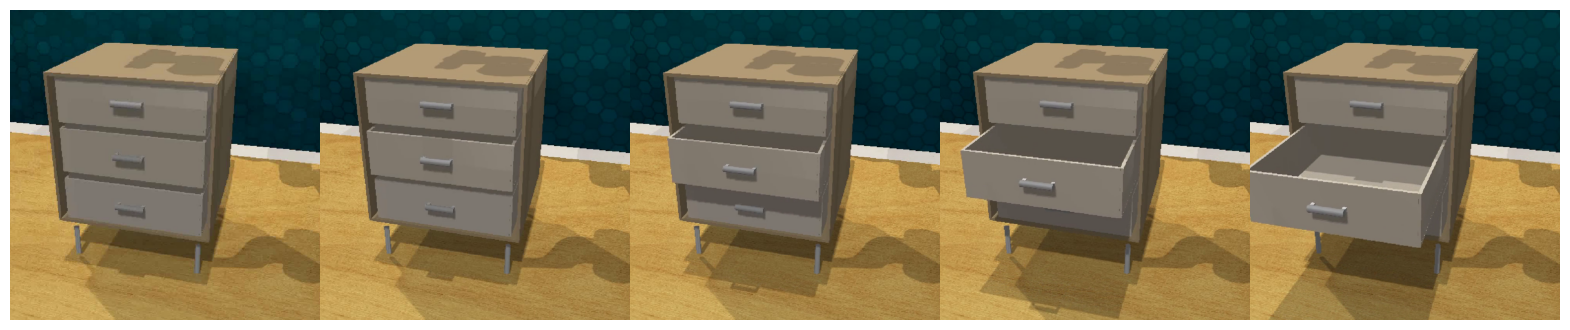

In [6]:
show_video(video_path)

Let's extract the first frame from the video and use that as the image prompt

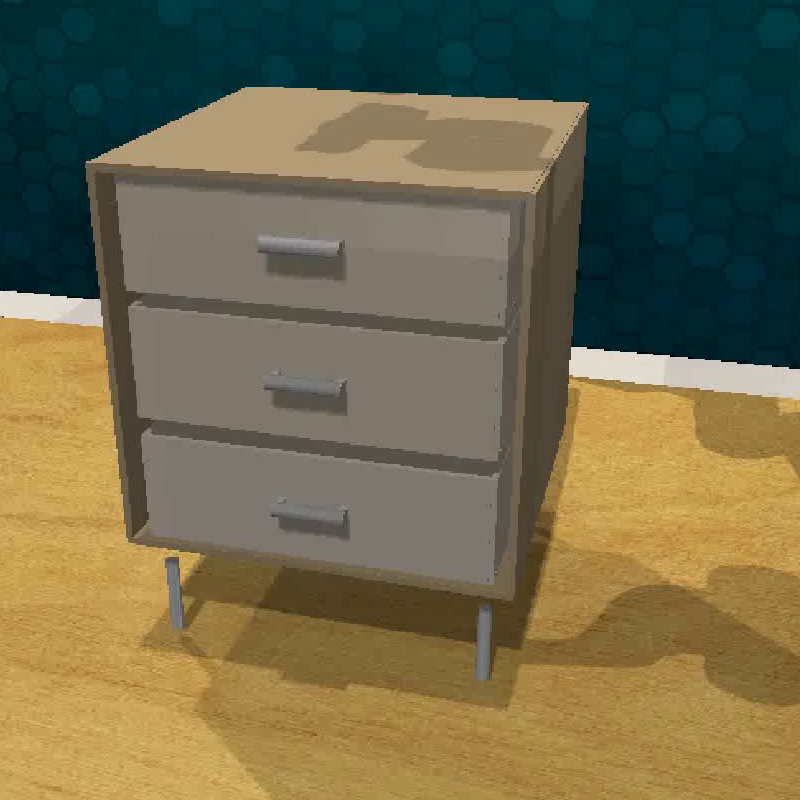

In [7]:
frames = get_frames_from_video(video_path,num_frames=5,)
frames[0]

In [8]:
if not os.path.exists("datasets/in-the-wild-dataset/images"):
    os.makedirs("datasets/in-the-wild-dataset/images")
image_path = f"datasets/in-the-wild-dataset/images/{task}.png"
frames[0].save(image_path)

We can annotate the motion in the video using Cotracker

In [9]:
cfg = load_config()

/home/link/miniconda3/envs/articulate-anything-clean/lib/python3.9/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


Before starting articulation, please make sure that the dataset is preprocessed by running

   ```bash
   python articulate_anything/preprocess/preprocess_partnet.py parallel={int} modality={image}
   ```
This renders a front-view image for each object in the PartNet-Mobility dataset. This is necessary for our mesh retrieval as we will compare the visual similarity between the input image or video against each rendered template object.

In [10]:
modality = "image"
prompt = image_path

Note: currently Gemini does not support multi-modal prompt finetuning. We have to use few-shot prompting instead. It's important to pick the examples with some care for your use case.

In [11]:
cfg = load_config()
cfg.prompt = prompt
cfg.modality = modality
cfg.out_dir = join_path("results", modality, task)



use_cotracker = True # {True, False}
mode = "image"
actor_prompting_type = "basic" # {basic, incontext}
critic_prompting_type = "incontext" # {basic, incontext}

cfg.joint_actor.mode = mode
cfg.joint_actor.use_cotracker = use_cotracker
cfg.joint_actor.type = actor_prompting_type
cfg.joint_actor.targetted_affordance = False

cfg.joint_actor.examples_dir = "datasets/multi_modal_incontext_examples/joint_actor/in_context_actor_examples_datasets" ## Put your examples here


cfg.joint_critic.mode = mode
cfg.joint_critic.use_cotracker = use_cotracker
cfg.joint_critic.type = critic_prompting_type

cfg.joint_critic.examples_dir = "datasets/multi_modal_incontext_examples/joint_critic/in_context_examples_datasets" ## Put your examples here

cfg.actor_critic.actor_only = True

## important to set correctly for the joint_critic to works properly
## this should have the same direction as the ground-truth video
cfg.simulator.flip_video = False ## flip time for suitcase
cfg.simulator.ray_tracing=False
cfg.simulator.floor_texture = "plain"


cfg.category_selector.topk = 3
# cfg.category_selector.topk = 1 ## how many top categories should we search for an object template match
# this is because PartNet-Mobility dataset categories labels are sparse and sometimes not great


cfg.obj_selector.frame_index = 0

cfg.actor_critic.max_iter = 2
# cfg.model_name = "gemini-1.5-flash"
cfg.model_name = "claude-3-5-sonnet-latest"#"gpt-4o"#


cfg.api_key = API_KEY ## loaded from .env file

cfg.actor_critic.start_seed = 1
cfg.gen_config.overwrite = True

In [12]:
steps = articulate(cfg);

INFO:root:Setting seed 1
INFO:root:Starting Mesh Retrieval
INFO:root:ObjectDetector: Generating content.
INFO:root:Prompt: ['The video is\n', <PIL.Image.Image image mode=RGB size=800x800 at 0x7E2AEEA0CF70>]
INFO:httpx:HTTP Request: POST https://ai-gateway.mytkhgroup.com/chat/completions "HTTP/1.1 200 OK"
INFO:root:ObjectSelector: Generating content.


candidate_obj_ids ['35059', '38516', '40147', '40417', '40453', '41003', '41004', '41083', '41085', '41086', '41452', '41510', '41529', '44781', '44817', '44826', '44853', '44962', '45001', '45007', '45087', '45091', '45092', '45130', '45132', '45134', '45135', '45146', '45159', '45162', '45164', '45166', '45168', '45173', '45176', '45177', '45178', '45189', '45194', '45203', '45212', '45213', '45219', '45235', '45238', '45243', '45244', '45247', '45248', '45249', '45261', '45267', '45271', '45290', '45297', '45305', '45323', '45332', '45354', '45372', '45374', '45378', '45387', '45397', '45403', '45413', '45415', '45419', '45423', '45427', '45444', '45448', '45463', '45503', '45504', '45505', '45516', '45523', '45526', '45573', '45575', '45594', '45600', '45606', '45612', '45620', '45621', '45622', '45623', '45632', '45633', '45636', '45638', '45645', '45662', '45667', '45670', '45676', '45677', '45687', '45689', '45690', '45691', '45693', '45694', '45696', '45699', '45710', '45717', 

INFO:root:Prompt: ['Here is the target image:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=800x800 at 0x7E2AEE961F40>, '\n\nHere are the candidate images (numbered starting from 0):\n', '\nImage 0:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A41C0>, '\nImage 1:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A41F0>, '\nImage 2:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4250>, '\nImage 3:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A42B0>, '\nImage 4:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4310>, '\nImage 5:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4370>, '\nImage 6:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A43D0>, '\nImage 7:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4430>, '\nImage 8:\n', <PIL.PngIm

json_str: {
    "image_description": "The target image shows a small dresser or chest of drawers with three equally-sized drawers stacked vertically. Each drawer has a horizontal handle in the center. The unit stands on four small metal legs. It has a flat top surface and appears to be a simple, modern design with clean lines. The overall proportions are roughly cubic.",
    "selected_image": "Image 3",
    "reasoning": "Image 3 is the most similar to the target image for these reasons:
    1. It has a similar overall rectangular/box-like structure
    2. It features multiple horizontal drawer-like sections
    3. It has similar hardware/handles on the front
    4. It has a similar modern, minimalist design aesthetic
    
    The other images differ significantly:
    - Images 0 and 6 are single-door tall cabinets
    - Images 1 and 9 are wall-mounted or shallow cabinet designs
    - Image 2 and 7 have different door/drawer configurations
    - Images 5 and 8 are tall wardrobes with ve

INFO:root:Prompt: ['Here is the target image:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=800x800 at 0x7E2AEE961F40>, '\n\nHere are the candidate images (numbered starting from 0):\n', '\nImage 0:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4550>, '\nImage 1:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A45B0>, '\nImage 2:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4610>, '\nImage 3:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4670>, '\nImage 4:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A46D0>, '\nImage 5:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4730>, '\nImage 6:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4790>, '\nImage 7:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A47F0>, '\nImage 8:\n', <PIL.PngIm

json_str: {
    "image_description": "The target image shows a three-drawer chest or dresser with a modern design. It has three equally-sized drawers stacked vertically, each with a horizontal handle. The unit stands on small metal legs and has a flat top surface. The overall construction is simple and clean-lined, with a minimalist aesthetic.",
    "selected_image": "Image 7",
    "reasoning": "Image 7 is the closest match to the target image because:
    1. It has the exact same configuration of three equally-sized drawers
    2. Similar handle style with horizontal pulls on each drawer
    3. Matching proportions and overall shape
    4. Similar minimalist, clean-lined design aesthetic

    The other images were not selected because:
    - Images 0, 2, and 9 are horizontal wall cabinets rather than vertical drawer units
    - Image 1 appears to be a single-door cabinet
    - Image 3 is a two-door cabinet with different hardware
    - Image 4 has four drawers instead of three
    - I

INFO:root:Prompt: ['Here is the target image:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=800x800 at 0x7E2AEE961F40>, '\n\nHere are the candidate images (numbered starting from 0):\n', '\nImage 0:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4910>, '\nImage 1:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4970>, '\nImage 2:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A49D0>, '\nImage 3:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4A30>, '\nImage 4:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4A90>, '\nImage 5:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4AF0>, '\nImage 6:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4B50>, '\nImage 7:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4BB0>, '\nImage 8:\n', <PIL.PngIm

json_str: {
    "image_description": "The target image shows a modern three-drawer chest or dresser with a clean, minimalist design. It features three equally-sized drawers stacked vertically, each with a horizontal metal handle in the center. The unit stands on small metal legs and has a flat top surface. The overall shape is rectangular and boxy.",
    "selected_image": "Image 4",
    "reasoning": "Image 4 is the closest match to the target image because:
    1. It has the same three-drawer configuration
    2. Similar proportions and overall rectangular shape
    3. Each drawer has a centered handle
    4. The drawers are stacked vertically in the same way
    
    Other images were rejected because:
    - Images 0, 1, and 5 are horizontal wall-mounted units
    - Images 7 and 9 are single-door cabinets
    - Image 2 has four drawers instead of three
    - Image 3 appears to be a single tall cabinet
    - Image 6, while having three drawers, has long horizontal handles instead of sm

INFO:root:Prompt: ['Here is the target image:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=800x800 at 0x7E2AEE961F40>, '\n\nHere are the candidate images (numbered starting from 0):\n', '\nImage 0:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4CD0>, '\nImage 1:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4D30>, '\nImage 2:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4D90>, '\nImage 3:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4DF0>, '\nImage 4:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4E50>, '\nImage 5:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4EB0>, '\nImage 6:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4F10>, '\nImage 7:\n', <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x480 at 0x7E2AEE7A4F70>, '\nImage 8:\n', <PIL.PngIm

json_str: {
    "image_description": "The target image shows a modern three-drawer chest or dresser with a clean, minimalist design. It features three equally-sized drawers stacked vertically, each with a horizontal handle. The unit stands on metal legs, raising it slightly off the ground. The top surface appears to have a different finish or material than the drawer fronts. The overall proportions are roughly cubic, with the height being slightly greater than the width.",
    "selected_image": "None of the provided images",
    "reasoning": "None of the candidate images match the key characteristics of the target image. The target image shows a distinctive three-drawer chest with metal legs, while the candidate images show various storage units that are fundamentally different:
    - Images 0, 3, 4, 7, and 9 show tall single-door cabinets
    - Image 1 shows a horizontal storage chest
    - Image 2 shows a base cabinet with a single drawer and door
    - Images 5 and 6 show wall-mount

## Mesh Retrieval

Let's inspect the steps starting with the mesh retrieval

In [13]:
mesh_retrieval = steps["Mesh Retrieval"]

In [14]:
mesh_retrieval["Category Selection"].load_prediction()

KeyError: 'Category Selection'

In [18]:
obj_selector = mesh_retrieval["Object Selection"]
obj_selector.load_prediction()

{'selected_image': 'Image 4',
 'obj_ids': ['7263', '7349', '101971', '103465', '103475', '103556'],
 'obj_id': '7263'}

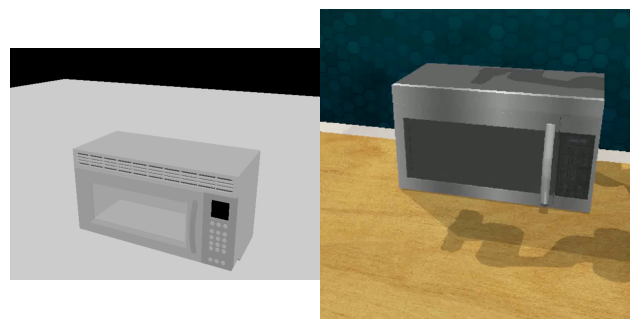

In [19]:
obj_selector.load_predicted_rendering()

## Link Placement

In [20]:
link_art = steps["Link Articulation"]
link_actors = link_art["Link actor"]
link_critics = link_art["Link critic"]
assert len(link_actors) == len(link_critics)
print(f"Link placement runs for {len(link_actors)} iteration(s)")

Link placement runs for 1 iteration(s)


In [21]:
link_codes = [link_actor.load_prediction() for link_actor in link_actors]

link_preds = [link_actor.load_predicted_rendering() for link_actor in link_actors]

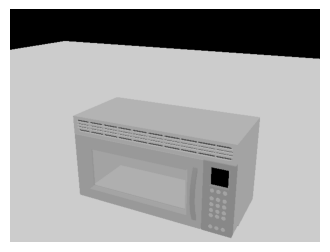

╷  
                                                                                │  
╶───────────────────────────────────────────────────────────────────────────────┼─╴
 from articulate_anything.api.odio_urdf import *                                │  
                                                                                │  
 def partnet_7263(input_dir, links):                                            │  
     """                                                                        │  
     No. masked_links: 21                                                       │  
     Robot Link Summary:                                                        │  
     - base                                                                     │  
     - door                                                                     │  
     - button                                                                   │  
     - button_2                                                                 │  
     - button_3                                                                 │  
     - button_4                                                                 │  
     - button_5                                                                 │  
     - button_6                                                                 │  
     - button_7                                                                 │  
     - button_8                                                                 │  
     - button_9                                                                 │  
     - button_10                                                                │  
     - button_11                                                                │  
     - button_12                                                                │  
     - button_13                                                                │  
     - button_14                                                                │  
     - button_15                                                                │  
     - button_16                                                                │  
     - button_17                                                                │  
     - button_18                                                                │  
     - microwave_body                                                           │  
                                                                                │  
     Object: A microwave with a door and multiple buttons.                      │  
     """                                                                        │  
     pred_robot = Robot(input_dir=input_dir, name="microwave")                  │  
     pred_robot.add_link(links['base'])                                         │  
     pred_robot.add_link(links['microwave_body'])                               │  
     pred_robot.add_joint(Joint("base_to_microwave_body",                       │  
                                Parent("base"),                                 │  
                                Child("microwave_body"),                        │  
                                type="fixed"),                                  │  
                          )                                                     │  
                                                                                │  
     pred_robot.add_link(links['door'])                                         │  
     pred_robot.place_relative_to('door', 'microwave_body',                     │  
                                  placement="front",                            │  
                                  clearance=0.0)                                │  
                                                                                │  
     for button_idx in range(18):                                               │  
         button_link = "button" if button_idx ==

In [22]:
show_images(link_preds)
display_codes(link_codes)

Note: 
1. some object part names need relabeling because PartNet-Mobility part labeling is not great. For example, a lid's pump rod would be labeled as `lid` or a door knob would be labeled as `door`. **solution**: gemini annotation based on mesh images + maybe some manual relabeling. This is done automatically by the `preprocess_partnet.py` script.
2. Some meshes are also not "clean" so there would be floating points in the air that affect our collision detection algorithm  and thus our link placement but might not immediate visible to the eye. **solution**: use [open3d](https://www.open3d.org/docs/release/tutorial/geometry/mesh.html#Connected-components) to clean up the meshes.

## Joint Prediction

In [23]:
joint_art = steps["Joint Articulation"]
joint_actors = joint_art["Joint actor"]


print(f"Joint prediction runs for {len(joint_actors)} iteration(s)")

Joint prediction runs for 1 iteration(s)


In [24]:
joint_codes = [joint_actor.load_prediction() for joint_actor in joint_actors]
joint_preds = [joint_actor.load_predicted_rendering() for joint_actor in joint_actors]


BEFORE FILTER VIDEO ['video_microwave_body_to_button_2_frontview.mp4', 'video_microwave_body_to_button_7_frontview.mp4', 'video_microwave_body_to_button_14_frontview.mp4', 'video_microwave_body_to_button_17_frontview.mp4', 'video_microwave_body_to_button_15_frontview.mp4', 'video_microwave_body_to_button_12_frontview.mp4', 'video_microwave_body_to_button_11_frontview.mp4', 'video_microwave_body_to_button_16_frontview.mp4', 'video_microwave_body_to_button_3_frontview.mp4', 'video_microwave_body_to_button_9_frontview.mp4', 'video_microwave_body_to_button_18_frontview.mp4', 'video_microwave_body_to_button_4_frontview.mp4', 'video_microwave_body_to_button_13_frontview.mp4', 'video_microwave_body_to_door_frontview.mp4', 'video_microwave_body_to_button_frontview.mp4', 'video_microwave_body_to_button_5_frontview.mp4', 'video_microwave_body_to_button_10_frontview.mp4', 'video_microwave_body_to_button_6_frontview.mp4', 'video_microwave_body_to_button_8_frontview.mp4']


/home/link/miniconda3/envs/articulate-anything-clean/lib/python3.9/site-packages/cotracker/models/build_cotracker.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_

Video saved to ./results/image/microwave_RL_Bench/joint_actor/iter_0/seed_0/aug_video_microwave_body_to_button_2_frontview.mp4


""

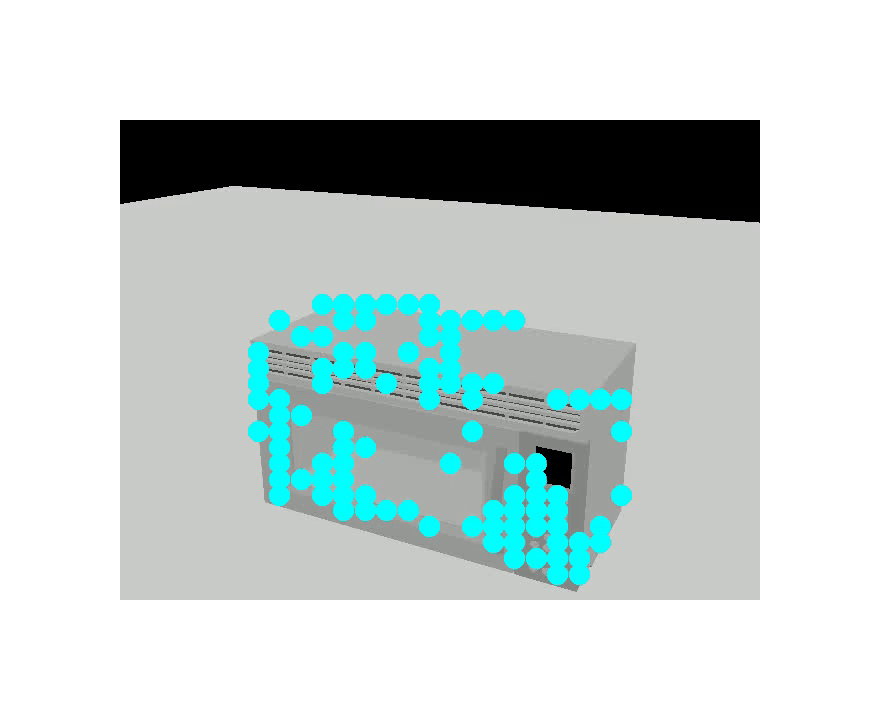

╷  
                                                                                                    │  
╶───────────────────────────────────────────────────────────────────────────────────────────────────┼─╴
 from articulate_anything.api.odio_urdf import *                                                    │  
                                                                                                    │  
 def partnet_7263(input_dir, links):                                                                │  
     """                                                                                            │  
     No. masked_links: 21                                                                           │  
     Robot Link Summary:                                                                            │  
     - base                                                                                         │  
     - door                                                                                         │  
     - button                                                                                       │  
     - button_2                                                                                     │  
     - button_3                                                                                     │  
     - button_4                                                                                     │  
     - button_5                                                                                     │  
     - button_6                                                                                     │  
     - button_7                                                                                     │  
     - button_8                                                                                     │  
     - button_9                                                                                     │  
     - button_10                                                                                    │  
     - button_11                                                                                    │  
     - button_12                                                                                    │  
     - button_13                                                                                    │  
     - button_14                                                                                    │  
     - button_15                                                                                    │  
     - button_16                                                                                    │  
     - button_17                                                                                    │  
     - button_18                                                                                    │  
     - microwave_body                                                                               │  
                                                                                                    │  
     Object: A microwave with a door and multiple buttons.                                          │  
     """                                                                                            │  
     pred_robot = Robot(input_dir=input_dir, name="microwave")                                      │  
     pred_robot.add_link(links['base'])                                                             │  
     pred_robot.add_link(links['microwave_body'])                                                   │  
     pred_robot.add_joint(Joint("base_to_microwave_body",                                           │  
                                Parent("base"),                                                     │  
                                Child("microwave_body"),                                            │  
                                type="fixed"

In [25]:
show_videos(joint_preds, width=512, height=512)
display_codes(joint_codes)